<a href="https://colab.research.google.com/github/maryo0oma51/Foundation-of-Data-Science-Spring-2025-2026/blob/main/Maryam_Ahli_MA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datascience
from datascience import *
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.8 MB/s eta 0:00:00


In [ ]:
from datascience import *
%matplotlib inline
#path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np

In [ ]:
# Load dataset
from sklearn.datasets import load_iris

# Load iris data from sklearn, then convert it to a datascience Table
iris_data = load_iris(as_frame=True)
df = iris_data.frame

# Rename columns to match the assignment style
df = df.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)': 'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)': 'petal_width',
    'target': 'species_num'
})

# Add species names
df['species'] = df['species_num'].replace({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Keep only the needed columns
df = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']]

# Convert pandas DataFrame to datascience Table
iris = Table.from_df(df)

iris.show(5)

sepal_length,sepal_width,petal_length,petal_width,species
5.1,3.5,1.4,0.2,setosa
4.9,3,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5,3.6,1.4,0.2,setosa


Task 1: Data Exploration (1 Mark)

In [ ]:
# Q1. How many rows and columns does the dataset have? Print the column names.
print("Number of rows:", iris.num_rows)
print("Number of columns:", iris.num_columns)
print("Column names:", iris.labels)

Number of rows: 150
Number of columns: 5
Column names: ('sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species')


In [ ]:
# Q2. How many flowers are there per species? Use the .group() method.
iris.group('species')

species,count
setosa,50
versicolor,50
virginica,50


In [ ]:
# Q3. Calculate the mean, minimum, and maximum of petal_length and petal_width using numpy. Show your results.
petal_length = iris.column('petal_length')
petal_width = iris.column('petal_width')

print("petal_length mean:", np.mean(petal_length))
print("petal_length min:", np.min(petal_length))
print("petal_length max:", np.max(petal_length))

print("petal_width mean:", np.mean(petal_width))
print("petal_width min:", np.min(petal_width))
print("petal_width max:", np.max(petal_width))

petal_length mean: 3.758
petal_length min: 1.0
petal_length max: 6.9
petal_width mean: 1.19933333333
petal_width min: 0.1
petal_width max: 2.5


Task 2: Visualization (2 Marks)

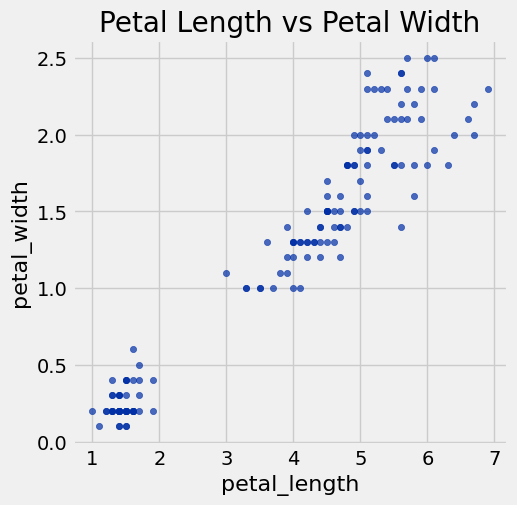

In [ ]:
# Q4. Create a scatter plot with petal_length on the x-axis and petal_width on the y-axis. Add a title to your plot.
iris.scatter('petal_length', 'petal_width')
plt.title('Petal Length vs Petal Width')
plt.show()

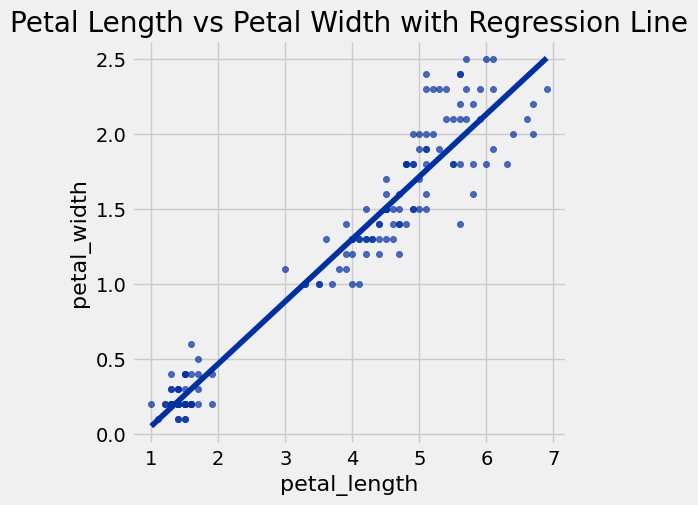

Comment: The scatter plot shows a clear positive linear relationship between petal_length and petal_width. As petal_length increases, petal_width also tends to increase, and the points stay fairly close to the line.


In [ ]:
# Q5. Add a regression line to the scatter plot using fit_line=True. In 1-2 sentences, describe the pattern you observe between the two variables.
iris.scatter('petal_length', 'petal_width', fit_line=True)
plt.title('Petal Length vs Petal Width with Regression Line')
plt.show()
print("Comment: The scatter plot shows a clear positive linear relationship between petal_length and petal_width. As petal_length increases, petal_width also tends to increase, and the points stay fairly close to the line.")

Task 3: Linear Regression (3 Marks)

In [ ]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)

In [ ]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))

In [ ]:
def slope(t, x, y):
    r = correlation(t, x, y)
    return r * np.std(t.column(y)) / np.std(t.column(x))

In [ ]:
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))

In [ ]:
# Q6. Using the helper functions above, compute and print the slope and intercept of the regression line that predicts petal_width from petal_length. Write the full regression equation.
B1 = slope(iris, 'petal_length', 'petal_width')
B0 = intercept(iris, 'petal_length', 'petal_width')

print("Slope =", B1)
print("Intercept =", B0)
print("Regression equation: predicted petal_width =", B1, "* petal_length +", B0)
print("or in simpler terms: y =", B0, "+", B1,"* x")

Slope = 0.415755416352
Intercept = -0.363075521319
Regression equation: predicted petal_width = 0.415755416352 * petal_length + -0.363075521319
or in simpler terms: y = -0.363075521319 + 0.415755416352 * x


In [ ]:
# Q7. Use your regression equation to predict the petal width of a flower with petal_length = 4.5 cm. Show your calculation.
x = 4.5
predicted_width = B1 * x + B0

print("Predicted petal width =", B1, "*", x, "+", B0)
print("Predicted petal width =", predicted_width)

Predicted petal width = 0.415755416352 * 4.5 + -0.363075521319
Predicted petal width = 1.50782385227


In [ ]:
# Q8. Compute the correlation coefficient r between petal_length and petal_width. Is the relationship strong or weak? Positive or negative? Explain in 2-3 sentences.
r = correlation(iris, 'petal_length', 'petal_width')
print("Correlation coefficient r =", r)

print("Comment: The correlation coefficient is positive and very close to 1, which means the relationship is strong and positive. This tells us that flowers with longer petals usually also have wider petals. Since the value is about 0.963, the linear association is very strong.")


Correlation coefficient r = 0.962865431403
Comment: The correlation coefficient is positive and very close to 1, which means the relationship is strong and positive. This tells us that flowers with longer petals usually also have wider petals. Since the value is about 0.963, the linear association is very strong.


Task 4: Residual Analysis (4 Marks)

In [ ]:
# Q9. Compute the predicted petal_width for every flower using your regression equation. Add both the predicted values and the residuals (actual - predicted) as new columns to the table. Display the first 8 rows.
predicted = B1 * iris.column('petal_length') + B0
residuals = iris.column('petal_width') - predicted

iris_with_predictions = iris.with_columns(
    'predicted_petal_width', predicted,
    'residual', residuals
)

iris_with_predictions.show(8)

sepal_length,sepal_width,petal_length,petal_width,species,predicted_petal_width,residual
5.1,3.5,1.4,0.2,setosa,0.218982,-0.0189821
4.9,3,1.4,0.2,setosa,0.218982,-0.0189821
4.7,3.2,1.3,0.2,setosa,0.177407,0.0225935
4.6,3.1,1.5,0.2,setosa,0.260558,-0.0605576
5,3.6,1.4,0.2,setosa,0.218982,-0.0189821
5.4,3.9,1.7,0.4,setosa,0.343709,0.0562913
4.6,3.4,1.4,0.3,setosa,0.218982,0.0810179
5,3.4,1.5,0.2,setosa,0.260558,-0.0605576


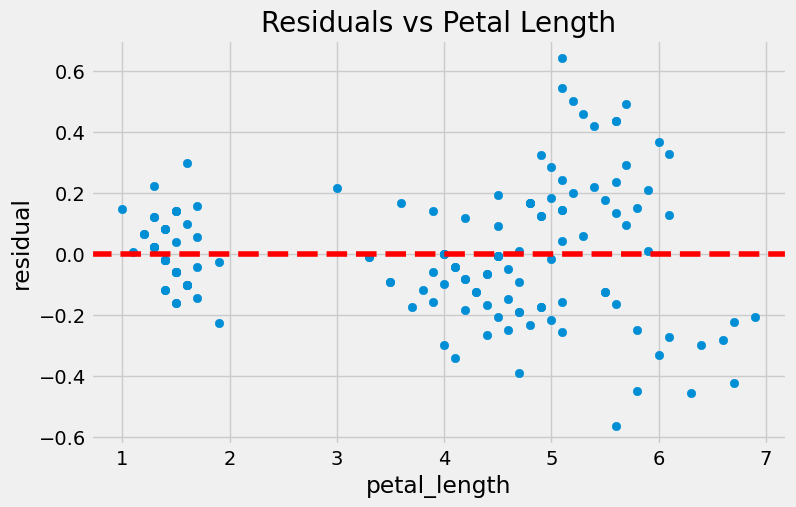

Comment: The residuals are scattered around 0, which suggests that the linear model captures the general trend reasonably well. However, the residuals are not perfectly random, so the relationship may not be perfectly linear for all flowers. Overall, the model is a good fit, but not exact.


In [ ]:
# Q10. Create a scatter plot of the residuals (y-axis) vs petal_length (x-axis). Add a horizontal red dashed line at y = 0. In 2-3 sentences, interpret what this plot tells you about how well the linear model fits the data.

plt.figure(figsize=(8, 5))
plt.scatter(iris_with_predictions.column('petal_length'), iris_with_predictions.column('residual'))
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('petal_length')
plt.ylabel('residual')
plt.title('Residuals vs Petal Length')
plt.show()
print("Comment: The residuals are scattered around 0, which suggests that the linear model captures the general trend reasonably well. However, the residuals are not perfectly random, so the relationship may not be perfectly linear for all flowers. Overall, the model is a good fit, but not exact.")

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)